In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

from keras.preprocessing.image import ImageDataGenerator

In [6]:

#Generate a Dataset

image_size = (256, 256)
batch_size = 32

#Get images for training
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_new",
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

#Get images for testing
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset_new",
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)



Found 1448 files belonging to 2 classes.
Using 1159 files for training.
Found 1448 files belonging to 2 classes.
Using 289 files for validation.


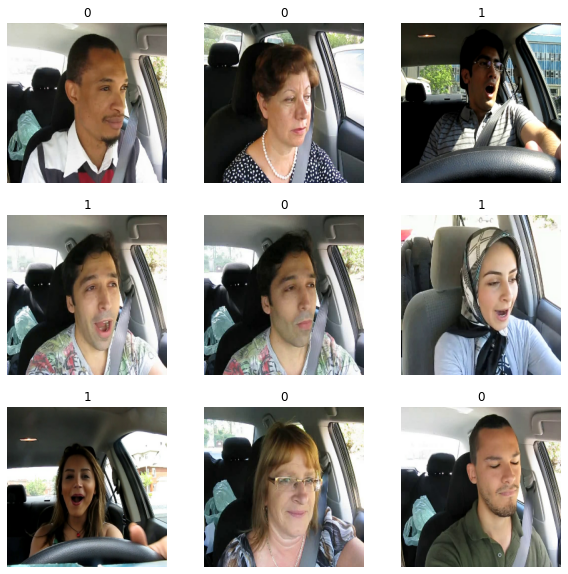

In [16]:
import matplotlib.pyplot as plt

#Display the first 9 images in the training set
#0 = no yawn, 1 = yawn

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [7]:
#Create the CNN


num_classes=1

model = keras.Sequential(
    [
        keras.Input(shape=(256,256,3)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="sigmoid"),
    ]
)

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 254, 254, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 127, 127, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 125, 125, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 62, 62, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 246016)            0         
_________________________________________________________________
dropout (Dropout)            (None, 246016)            0         
_________________________________________________________________
dense (Dense)                (None, 1)                 2

In [8]:
#Train the model

batch_size = 128
epochs = 6

model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(train_ds, batch_size=batch_size, epochs=epochs)
#validation_data=val_ds,

Epoch 1/6
37/37 [==============================] - 32s 866ms/step - loss: 56.0364 - accuracy: 0.6074
Epoch 2/6
37/37 [==============================] - 30s 813ms/step - loss: 0.4926 - accuracy: 0.7472
Epoch 3/6
37/37 [==============================] - 30s 803ms/step - loss: 0.3158 - accuracy: 0.8645
Epoch 4/6
37/37 [==============================] - 30s 815ms/step - loss: 0.2197 - accuracy: 0.9198
Epoch 5/6
37/37 [==============================] - 31s 835ms/step - loss: 0.1634 - accuracy: 0.9439
Epoch 6/6
37/37 [==============================] - 30s 804ms/step - loss: 0.1455 - accuracy: 0.9482


In [19]:
#Save the model to be used later

model.save('model')

INFO:tensorflow:Assets written to: model\assets


In [9]:
#Accuracy on the Test set

model.evaluate(val_ds)[1]

10/10 [==============================] - 1s 140ms/step - loss: 0.3021 - accuracy: 0.9031


0.9031141996383667

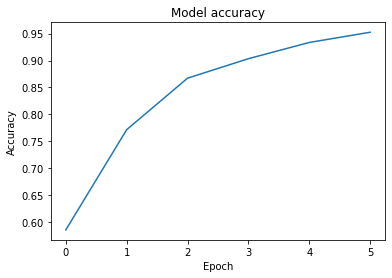

In [23]:
#Create a plot of model accuracy during training

plt.plot(history.history['accuracy'])
#plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
#plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

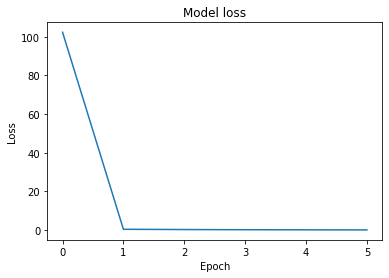

In [24]:
#graph of model loss

plt.plot(history.history['loss'])
#plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
#plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [22]:
#Import a previously saved model to run the code below
#instead of training the model again

model = tf.keras.models.load_model('model')
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 254, 254, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 127, 127, 32)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 125, 125, 64)      18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 62, 62, 64)        0         
_________________________________________________________________
flatten (Flatten)            (None, 246016)            0         
_________________________________________________________________
dropout (Dropout)            (None, 246016)            0         
_________________________________________________________________
dense (Dense)                (None, 1)                 2

# Testing Images

Not Tired


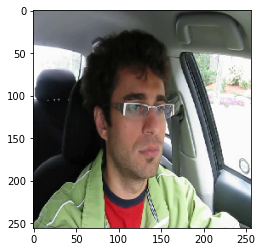

In [9]:
#Testing

#Preprocess the image
img = keras.preprocessing.image.load_img(
    "dataset_new/no_yawn/1006.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

#Make prediction
predictions = model.predict(img_array)
score = predictions[0]

plt.imshow(img)
#Model will predict 1 for tired, 0 for not tired
classPredict = (model.predict(img_array) > 0.5).astype("int32")
if classPredict == 0:
    print("Not Tired")
else:
    print("Tired")


[[1]]
Tired


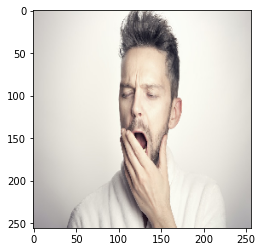

In [10]:
#Same as above with a different image

img = keras.preprocessing.image.load_img(
    "tired.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

classPredict = (model.predict(img_array) > 0.5).astype("int32")
print(classPredict)
if classPredict == 0:
    print("Not Tired")
else:
    print("Tired")
predictions = model.predict(img_array)
score = predictions[0]

plt.imshow(img)


[[1]]
Tired


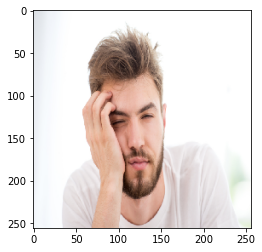

In [11]:
#Again same as above

img = keras.preprocessing.image.load_img(
    "tired3.png", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

classPredict = (model.predict(img_array) > 0.5).astype("int32")
print(classPredict)
if classPredict == 0:
    print("Not Tired")
else:
    print("Tired")
predictions = model.predict(img_array)
score = predictions[0]

plt.imshow(img)
#print("Accuracy:", score*100, "%")

[[0]]
Not Tired


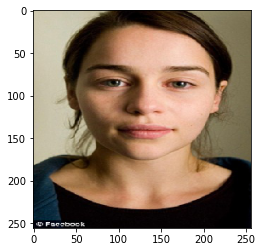

In [12]:
#Same as above

img = keras.preprocessing.image.load_img(
    "face.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

classPredict = (model.predict(img_array)).astype("int32")
print(classPredict)
if classPredict <= 0.5:
    print("Not Tired")
else:
    print("Tired")
predictions = model.predict(img_array)
score = predictions[0]

plt.imshow(img)
#print("Accuracy:", score*100, "%")

# Video Processing

In [26]:

#Capture a 5 second video using the webcam and save it

import cv2
import time
import os
from keras.models import load_model
import numpy as np

#For eye detection
face = cv2.CascadeClassifier('haar cascade files\haarcascade_frontalface_alt.xml')
leye = cv2.CascadeClassifier('haar cascade files\haarcascade_lefteye_2splits.xml')
reye = cv2.CascadeClassifier('haar cascade files\haarcascade_righteye_2splits.xml')

model = load_model('custmodel.h5')
path = os.getcwd()
cap = cv2.VideoCapture(0)
count=0
score=0
rpred=[99]
lpred=[99]

#Eye detection result - will be 0 for not tired or 1 for tired
eye_detection_result = 0

# The duration in seconds of the video captured
capture_duration = 5
i = 0

cap = cv2.VideoCapture(0)

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('test.mp4',fourcc, 20.0, (640,480))

start_time = time.time()

while( int(time.time() - start_time) < capture_duration ):  #For duration of video capture
    ret, frame = cap.read()
    cv2.imwrite("TestImages/" + str(i)+'.jpg', frame)  #Save each individual frame as image
    i = i + 1
    
    #Eye Detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face.detectMultiScale(gray,minNeighbors=5,scaleFactor=1.1,minSize=(25,25))
    left_eye = leye.detectMultiScale(gray)
    right_eye =  reye.detectMultiScale(gray)
    
    
    for (x,y,w,h) in faces:
            cv2.rectangle(frame, (x,y) , (x+w,y+h) , (100,100,100) , 1 )

    for (x,y,w,h) in right_eye:
        r_eye=frame[y:y+h,x:x+w]
        count=count+1
        r_eye = cv2.cvtColor(r_eye,cv2.COLOR_BGR2GRAY)
        r_eye = cv2.resize(r_eye,(24,24))
        r_eye= r_eye/255
        r_eye=  r_eye.reshape(24,24,-1)
        r_eye = np.expand_dims(r_eye,axis=0)
        rpred = model.predict_classes(r_eye)
        if(rpred[0]==1):
            lbl='Open' 
        if(rpred[0]==0):
            lbl='Closed'
        break

    for (x,y,w,h) in left_eye:
        l_eye=frame[y:y+h,x:x+w]
        count=count+1
        l_eye = cv2.cvtColor(l_eye,cv2.COLOR_BGR2GRAY)  
        l_eye = cv2.resize(l_eye,(24,24))
        l_eye= l_eye/255
        l_eye=l_eye.reshape(24,24,-1)
        l_eye = np.expand_dims(l_eye,axis=0)
        lpred = model.predict_classes(l_eye)
        if(lpred[0]==1):
            lbl='Open'   
        if(lpred[0]==0):
            lbl='Closed'
        break

    if(rpred[0]==0 and lpred[0]==0):
        score=score+1

    # if(rpred[0]==1 or lpred[0]==1):
    else:
        score=score-1


    if(score<0):
        score=0   

    if(score>15):  #Eyes are closed for a long time
        eye_detection_result = 1
    else:
        eye_detection_result = 0  # eyes were open, return 0 for not tired
    

cap.release()
out.release()
cv2.destroyAllWindows()

In [27]:
print(eye_detection_result)

0


In [ ]:


#Test each frame of the video
#Make list of classification for each frame
#Average the classification and make a final prediction for the whole video
import os
from pathlib import Path
import numpy as np
#import matplotlib.pyplot as plt

notTiredCount = 0 #number of frames predicted as not tired
tiredCount = 0 # number of frames predicted as tired
total = 0 #total number of frames

folder_dir = 'TestImages'
frameList = []  # holds the images


images = Path(folder_dir).glob('*.jpg')  # Path to each frame of video as images
for image in images:       #Add each image to a list
    frameList.append(image)

image_size = (256, 256)

# loop through the list of images
for i in range(len(frameList)):
    # Load the current image and make it into an array
    img = keras.preprocessing.image.load_img(
    frameList[i], target_size=image_size
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    # Expand the dims to fit
    img_array = tf.expand_dims(img_array, 0) 

    # Make a prediction using the image
    classPredict = (model.predict(img_array)> 0.5).astype("int32")
    
    # Increase the tired or not tired count based on the prediction
    if(classPredict == 0):
        notTiredCount+=1
    else:
        tiredCount+=1
        
    # Add to the total number of frames
    total+=1

    
    


print(notTiredCount)
print(tiredCount)
print(total)

#If there are more not tired frames than tired, predict not tired.
#If there are more tired frames than not tired, predict tired.
if notTiredCount > tiredCount:
    print("Not Tired")
elif tiredCount > notTiredCount:
    print("Tired")
else:
    print("Error")
